In [83]:
import laspy
import numpy as np
import pandas as pd
import lasio
import matplotlib.pyplot as plt
import plotly.express as px


In [ ]:
df = pd.read_excel("Formation Tops.xlsx")
df["Top depth [mMD_RKB]"] = df["Top depth [mMD_RKB]"].astype('float64')


In [53]:
df

,Well #,Formation,Top depth [mMD_RKB]
0,XX-X,FM-1,406.0
1,XX-X,FM-2,478.0
2,XX-X,FM-3,639.0
3,XX-X,FM-4,674.0
4,XX-X,FM-5,702.0
5,XX-X,FM-6,729.0
6,XX-X,FM-7,790.0
7,XX-X,FM-8,807.0
8,XX-X,FM-9,1168.0
9,XX-X,FM-10,1517.0


In [17]:
las = lasio.read("Well Log.LAS")

In [19]:
df_logs = las.df()
df_logs


,AC,ACS,BS,CALI,DEN,DENC,GR,K,NEU,PEF,RDEP,RMED,RMIC,ROP,TH,U
DEPT,,,,,,,,,,,,,,,,
405.9936,NaN,NaN,26.0,NaN,NaN,NaN,78.5885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.1460,NaN,NaN,26.0,NaN,NaN,NaN,84.2673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.2984,NaN,NaN,26.0,NaN,NaN,NaN,83.9706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.4508,NaN,NaN,26.0,NaN,NaN,NaN,83.9938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.6032,NaN,NaN,26.0,NaN,NaN,NaN,76.8121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2209.6476,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.6901,NaN,NaN
2209.8000,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.7076,NaN,NaN
2209.9524,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.1661,NaN,NaN


In [31]:
df_logs["Vp/Vs"] = df_logs["AC"] / df_logs["ACS"]


In [41]:
df_logs.columns

Index(['AC', 'ACS', 'BS', 'CALI', 'DEN', 'DENC', 'GR', 'K', 'NEU', 'PEF',
       'RDEP', 'RMED', 'RMIC', 'ROP', 'TH', 'U', 'Vp/Vs'],
      dtype='object')

In [42]:
df_logs["AI"] = df_logs["AC"]* df_logs["DEN"]

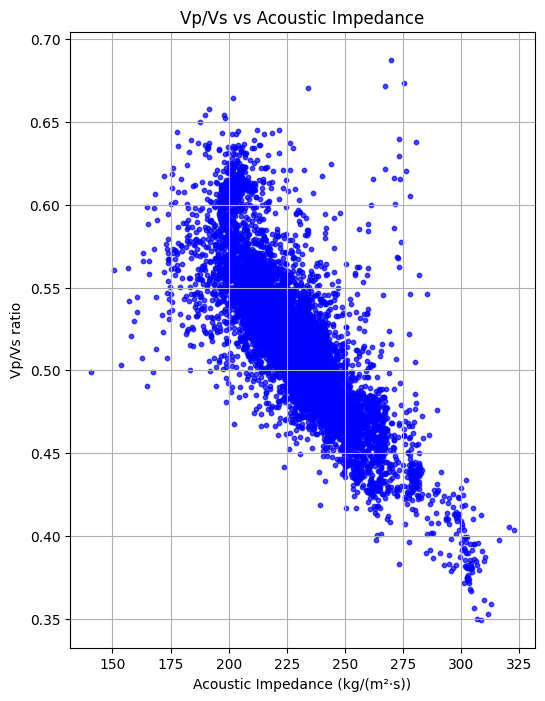

In [ ]:
plt.figure(figsize=(6,8))
plt.scatter(df_logs["AI"], df_logs["Vp/Vs"], c='blue', s=10, alpha=0.7)

plt.xlabel("Acoustic Impedance (kg/(m²·s))")
plt.ylabel("Vp/Vs ratio")
plt.title("Vp/Vs vs Acoustic Impedance")
plt.grid(True)
plt.show()


In [54]:
df_logs_with_form = pd.merge_asof(
    df_logs.sort_values("DEPT"),
    df,
    left_on="DEPT",
    right_on="Top depth [mMD_RKB]",
    direction="backward"
)


In [55]:
df_logs_with_form

,AC,ACS,BS,CALI,DEN,DENC,GR,K,NEU,PEF,...,RMED,RMIC,ROP,TH,U,Vp/Vs,AI,Well #,Formation,Top depth [mMD_RKB]
0,NaN,NaN,26.0,NaN,NaN,NaN,78.5885,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,26.0,NaN,NaN,NaN,84.2673,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
2,NaN,NaN,26.0,NaN,NaN,NaN,83.9706,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
3,NaN,NaN,26.0,NaN,NaN,NaN,83.9938,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
4,NaN,NaN,26.0,NaN,NaN,NaN,76.8121,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11835,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,16.6901,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11836,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,15.7076,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11837,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,13.1661,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11838,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,12.8002,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0


In [62]:
df_clean = df_logs_with_form.rename(columns={"Top depth [mMD_RKB]": "Depth"})


In [63]:
df_clean

,AC,ACS,BS,CALI,DEN,DENC,GR,K,NEU,PEF,...,RMED,RMIC,ROP,TH,U,Vp/Vs,AI,Well #,Formation,Depth
0,NaN,NaN,26.0,NaN,NaN,NaN,78.5885,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,26.0,NaN,NaN,NaN,84.2673,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
2,NaN,NaN,26.0,NaN,NaN,NaN,83.9706,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
3,NaN,NaN,26.0,NaN,NaN,NaN,83.9938,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
4,NaN,NaN,26.0,NaN,NaN,NaN,76.8121,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11835,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,16.6901,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11836,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,15.7076,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11837,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,13.1661,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11838,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,12.8002,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0


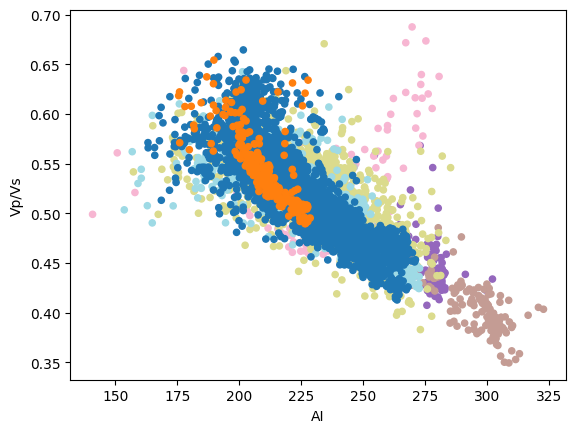

In [ ]:
df['Formation_code'] = pd.Categorical(df['Formation']).codes

# Simple scatter
plt.scatter(df_clean['AI'],df_clean['Vp/Vs'], c=df['Formation_code'], cmap='tab20', s=20)
plt.gca() # depth usually goes downward
plt.xlabel('AI')      # replace with your X-axis
plt.ylabel('Vp/Vs')
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Ensure formations are categorical
df['Formation'] = df['Formation'].astype(str)

fig = px.scatter_3d(
    df_clean,
    x='AI',
    ,
    y='Vp/Vs',
    color='Formation',   # automatically colors by formation name
    size_max=5
)

fig.update_layout(scene=dict(zaxis=dict(autorange='reversed')))  # Depth goes downward
fig.show()


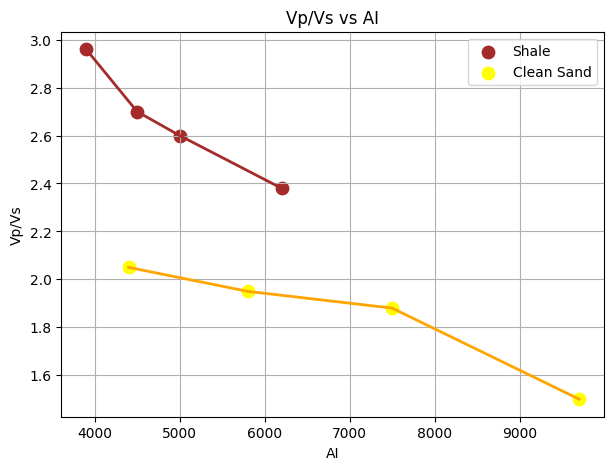

In [ ]:
#Ca, egenlagd template basert på ødegaard sine empiriske data.
shale = [(3900, 2.96), (4500, 2.7), (5000, 2.6), (6200, 2.38)]

clean_sand = [(4400, 2.05), (5800, 1.95), (7500, 1.88), (9700, 1.5)]

shale_x, shale_y = zip(*shale)
sand_x, sand_y = zip(*clean_sand)

plt.figure(figsize=(7,5))
plt.scatter(shale_x, shale_y, color='brown', label='Shale', s=80)
plt.scatter(sand_x, sand_y, color='yellow', label='Clean Sand', s=80)
plt.plot(shale_x, shale_y, color='brown', linestyle='-', linewidth=2)
plt.plot(sand_x, sand_y, color='orange', linestyle='-', linewidth=2)
plt.xlabel('AI')
plt.ylabel('Vp/Vs')
plt.title('Vp/Vs vs AI')
plt.legend()
plt.grid(True)
plt.show()


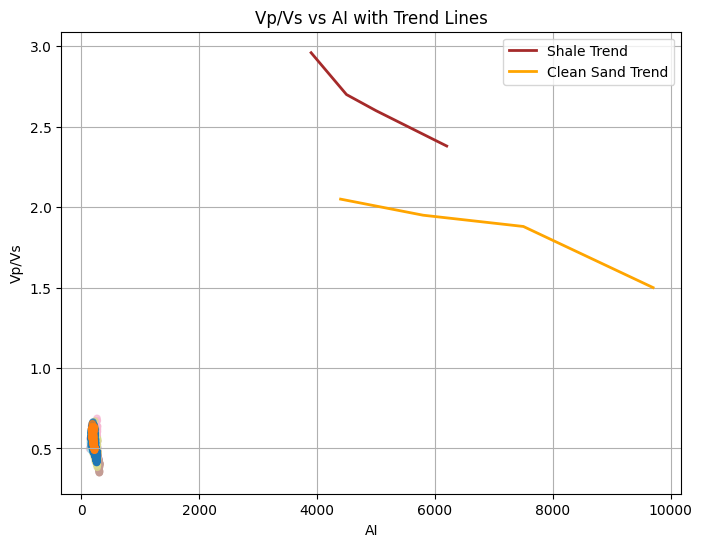

In [94]:
shale = [(3900, 2.96), (4500, 2.7), (5000, 2.6), (6200, 2.38)]
clean_sand = [(4400, 2.05), (5800, 1.95), (7500, 1.88), (9700, 1.5)]

shale_x, shale_y = zip(*shale)
sand_x, sand_y = zip(*clean_sand)

# Scatter from your dataframe
# Assuming df_clean has columns: 'AI', 'Vp/Vs', 'Formation'
df['Formation_code'] = pd.Categorical(df['Formation']).codes

plt.figure(figsize=(8,6))

# Scatter of actual data (colored by formation)
plt.scatter(df_clean['AI'], df_clean['Vp/Vs'], 
            c=df['Formation_code'], cmap='tab20', s=20, alpha=0.7)

# Plot trend lines (shale and sand)
plt.plot(shale_x, shale_y, color='brown', linestyle='-', linewidth=2, label='Shale Trend')
plt.plot(sand_x, sand_y, color='orange', linestyle='-', linewidth=2, label='Clean Sand Trend')

plt.xlabel('AI')
plt.ylabel('Vp/Vs')
plt.title('Vp/Vs vs AI with Trend Lines')
plt.legend()
plt.grid(True)
plt.show()


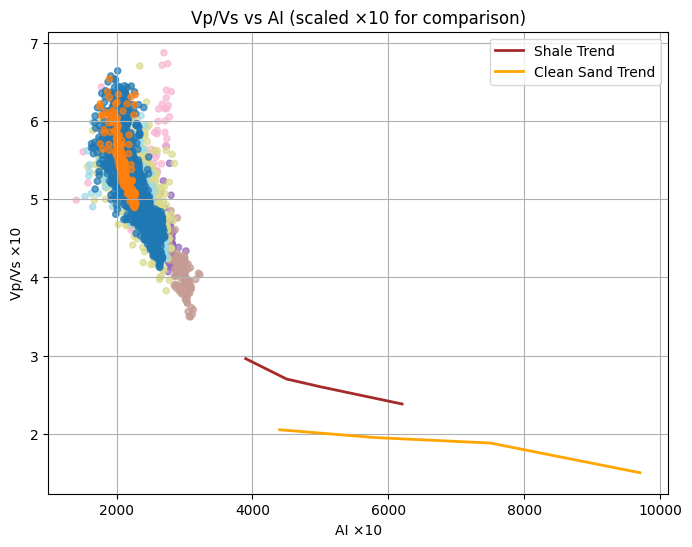

In [96]:


# Trend lines
shale = [(3900, 2.96), (4500, 2.7), (5000, 2.6), (6200, 2.38)]
clean_sand = [(4400, 2.05), (5800, 1.95), (7500, 1.88), (9700, 1.5)]

shale_x, shale_y = zip(*shale)
sand_x, sand_y = zip(*clean_sand)

plt.figure(figsize=(8,6))

# Scatter of your data scaled 10x on both axes
plt.scatter(df_clean['AI']*10, df_clean['Vp/Vs']*10, 
            c=df['Formation_code'], cmap='tab20', s=20, alpha=0.7)

# Plot trend lines normally
plt.plot(shale_x, shale_y, color='brown', linestyle='-', linewidth=2, label='Shale Trend')
plt.plot(sand_x, sand_y, color='orange', linestyle='-', linewidth=2, label='Clean Sand Trend')

plt.xlabel('AI ×10')
plt.ylabel('Vp/Vs ×10')
plt.title('Vp/Vs vs AI (scaled ×10 for comparison)')
plt.legend()
plt.grid(True)
plt.show()
